# A2 — Knowledge-base evidence: layout, OCR, chunking, embeddings, and FAISS

The preserved Phase 5–7 outputs below are prior evidence. The new Phase 7 index cells clone `junaid`, print its exact commit, compare models/chunking on fixed Bangla queries, and verify a full FAISS restart. Kaggle does not create Git commits or push to GitHub. Save a Kaggle version with outputs, download this `.ipynb`, and commit the executed file from the local repository. The existing Qwen3-VL drafts are evaluated from `grading_kit/labels.jsonl`; the expensive Qwen model is not rerun.

In [1]:
from pathlib import Path
import os, subprocess, sys

REPO_URL = "https://github.com/FAHIM-ISHTIAK/doc-agent-20.git"
REPO_BRANCH = "junaid"
REPO_DIR = Path("/kaggle/working/doc-agent-20-phase7-index")
ARTIFACT_DIR = Path("/kaggle/working/artifacts/phase7-index")

def run_command(command, cwd=None):
    print("$", " ".join(map(str, command)))
    result = subprocess.run([str(part) for part in command], cwd=str(cwd) if cwd else None, text=True, capture_output=True, check=False)
    if result.stdout.strip(): print(result.stdout.strip())
    if result.stderr.strip(): print(result.stderr.strip())
    if result.returncode != 0: raise RuntimeError(f"Command failed ({result.returncode}): {command}")
    return result

if REPO_DIR.exists():
    if not (REPO_DIR / ".git").is_dir(): raise RuntimeError(f"Refusing to replace non-Git path: {REPO_DIR}")
    if run_command(["git", "status", "--porcelain"], REPO_DIR).stdout.strip(): raise RuntimeError("Existing Kaggle clone is dirty; start a fresh session or use a new REPO_DIR")
    run_command(["git", "fetch", "origin"], REPO_DIR)
    run_command(["git", "switch", REPO_BRANCH], REPO_DIR)
    run_command(["git", "pull", "--ff-only", "origin", REPO_BRANCH], REPO_DIR)
else:
    run_command(["git", "clone", "--branch", REPO_BRANCH, "--single-branch", REPO_URL, str(REPO_DIR)])
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
os.chdir(REPO_DIR)
commit_hash = run_command(["git", "rev-parse", "HEAD"], REPO_DIR).stdout.strip()
print("TESTED GIT COMMIT:", commit_hash)
print("Kaggle creates no Git commit in this workflow.")

$ git clone --branch 2105001/phases-5-7 --single-branch https://github.com/FAHIM-ISHTIAK/doc-agent-20.git /kaggle/working/doc-agent-20-phase57
Cloning into '/kaggle/working/doc-agent-20-phase57'...
$ git rev-parse HEAD
d02dd7fdc1cf0f36f073cf90bc5ea22b57d2246a
TESTED GIT COMMIT: d02dd7fdc1cf0f36f073cf90bc5ea22b57d2246a
Kaggle creates no Git commit in this workflow.


In [2]:
PHASE57_PACKAGES = ["pydantic==2.12.3", "Pillow==11.3.0", "PyYAML==6.0.3", "PyMuPDF==1.26.7", "pytest==8.4.2", "easyocr==1.7.2", "sentence-transformers==5.7.0", "faiss-cpu==1.15.0", "psutil==7.2.2"]
run_command([sys.executable, "-m", "pip", "install", *PHASE57_PACKAGES])
run_command([sys.executable, "-m", "pip", "install", "-e", str(REPO_DIR), "--no-deps"])
if str(REPO_DIR / "src") not in sys.path: sys.path.insert(0, str(REPO_DIR / "src"))
test_result = run_command([sys.executable, "-m", "pytest", "tests/test_ingest.py", "tests/test_ocr.py", "tests/test_retrieval.py", "tests/test_contracts.py", "-q"], REPO_DIR)
print("PHASE 5-7 FOCUSED TESTS: PASS")

$ /usr/bin/python3 -m pip install pydantic==2.12.3 Pillow==11.3.0 PyYAML==6.0.3 PyMuPDF==1.26.7 pytest==8.4.2 easyocr==1.7.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.1/24.1 MB 69.9 MB/s eta 0:00:00
$ /usr/bin/python3 -m pip install -e /kaggle/working/doc-agent-20-phase57 --no-deps
Obtaining file:///kaggle/working/doc-agent-20-phase57
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
  Building editable for doc-agent (pyproject.toml): started
  Building editable for doc-agent (pyproject.toml): finished with status 'done'
  Created wheel for do

## Phase 5 — Real-page layout and reading order

In [3]:
import json
from copy import deepcopy
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image
from doc_agent import config
from doc_agent.contracts import Page
from doc_agent.vision import layout

cfg = config.load(REPO_DIR / "configs/config.yaml")
cfg = deepcopy(cfg)
cfg["device"] = "cuda" if __import__("torch").cuda.is_available() else "cpu"
cfg["data"]["artifact_dir"] = str(ARTIFACT_DIR)
labels = [json.loads(line) for line in (REPO_DIR / "grading_kit/labels.jsonl").read_text(encoding="utf-8").splitlines() if line.strip()]
pages_dir = REPO_DIR / "grading_kit/heldout_pages"
pages = [Page(id=item["page_id"], doc_id=item["doc_id"], image_path=str((pages_dir / item["image_filename"]).resolve())) for item in labels]
regions = layout.detect(pages, cfg)
regions_by_page = {page.id: [region for region in regions if region.page_id == page.id] for page in pages}
assert all(regions_by_page[page.id] for page in pages)
for page in pages:
    with Image.open(page.image_path) as image:
        width, height = image.size
    assert all(0 <= r.bbox[0] < r.bbox[2] <= width and 0 <= r.bbox[1] < r.bbox[3] <= height for r in regions_by_page[page.id])
print("Pages:", len(pages), "Regions:", len(regions))
print("Kinds:", {kind: sum(r.kind == kind for r in regions) for kind in ["heading", "text", "table", "figure"]})
print("PHASE 5 REAL-PAGE LAYOUT CONTRACT: PASS")

Pages: 12 Regions: 80
Kinds: {'heading': 17, 'text': 62, 'table': 1, 'figure': 0}
PHASE 5 REAL-PAGE LAYOUT CONTRACT: PASS


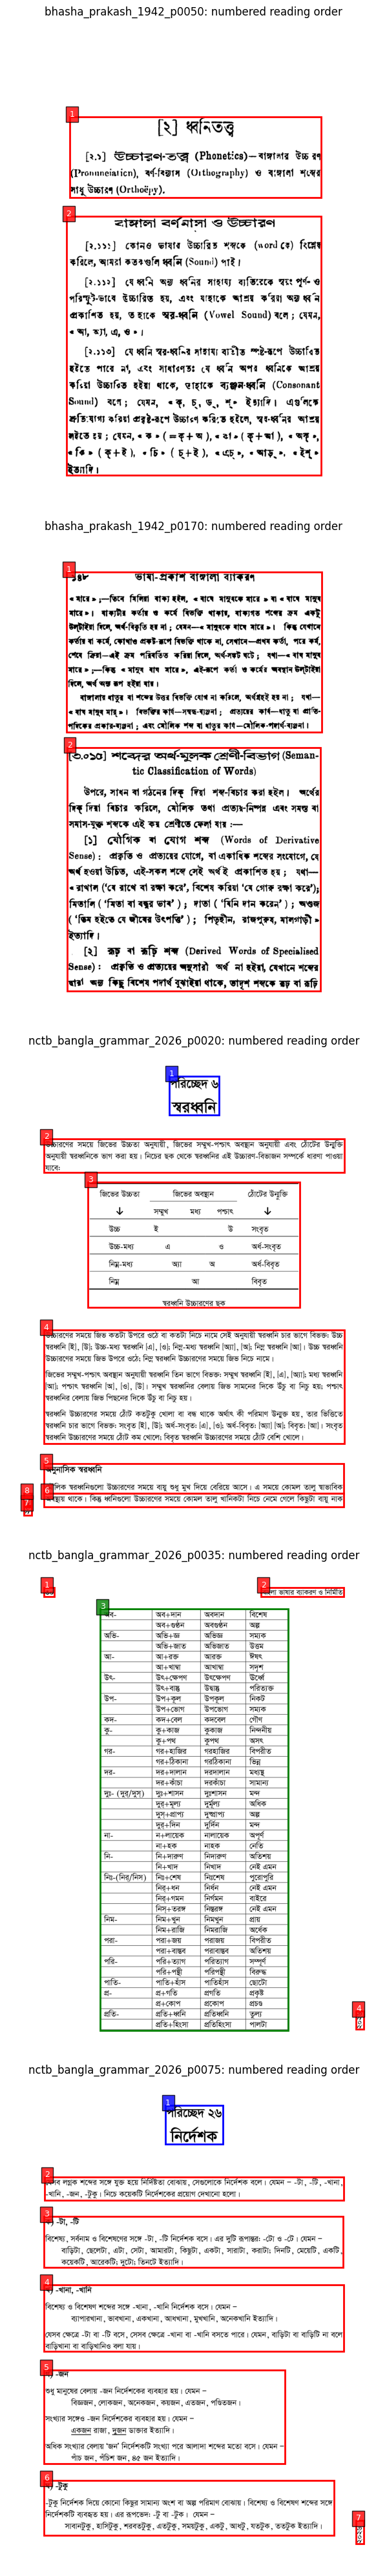

Visually verify region coverage, rule/example order, and atomic tables.
PHASE 5 LAYOUT GALLERY: READY FOR HUMAN CHECK


In [4]:
sample_ids = ["bhasha_prakash_1942_p0050", "bhasha_prakash_1942_p0170", "nctb_bangla_grammar_2026_p0020", "nctb_bangla_grammar_2026_p0035", "nctb_bangla_grammar_2026_p0075"]
sample_pages = [page for page in pages if page.id in sample_ids]
figure, axes = plt.subplots(len(sample_pages), 1, figsize=(14, 8 * len(sample_pages)))
if len(sample_pages) == 1: axes = [axes]
colors = {"heading": "blue", "text": "red", "table": "green", "figure": "purple"}
for axis, page in zip(axes, sample_pages):
    with Image.open(page.image_path) as source: preview = source.copy()
    axis.imshow(preview, cmap="gray")
    for order, region in enumerate(regions_by_page[page.id], start=1):
        x0, y0, x1, y1 = region.bbox
        axis.add_patch(Rectangle((x0, y0), x1-x0, y1-y0, fill=False, linewidth=2, edgecolor=colors[region.kind]))
        axis.text(x0, y0, str(order), color="white", fontsize=9, bbox={"facecolor": colors[region.kind], "alpha": 0.8})
    axis.set_title(f"{page.id}: numbered reading order")
    axis.axis("off")
plt.tight_layout(); plt.show()
print("Visually verify region coverage, rule/example order, and atomic tables.")
print("PHASE 5 LAYOUT GALLERY: READY FOR HUMAN CHECK")

## Phase 6 — EasyOCR pipeline and stored-candidate comparison

In [5]:
import time, unicodedata
from doc_agent.vision import ocr

def normalize_for_metric(text):
    return " ".join(unicodedata.normalize("NFC", text).split())

def edit_distance(left, right):
    previous = list(range(len(right) + 1))
    for i, a in enumerate(left, start=1):
        current = [i]
        for j, b in enumerate(right, start=1): current.append(min(current[-1]+1, previous[j]+1, previous[j-1]+(a != b)))
        previous = current
    return previous[-1]

def error_rates(predictions, golds, normalized=False):
    pairs = [(normalize_for_metric(p), normalize_for_metric(g)) if normalized else (p, g) for p, g in zip(predictions, golds)]
    char_errors = sum(edit_distance(list(p), list(g)) for p, g in pairs)
    char_total = sum(len(g) for _, g in pairs)
    word_errors = sum(edit_distance(p.split(), g.split()) for p, g in pairs)
    word_total = sum(len(g.split()) for _, g in pairs)
    return {"cer": char_errors/max(char_total, 1), "wer": word_errors/max(word_total, 1), "characters": char_total, "words": word_total}

reader = ocr.Reader(cfg)
pipeline_predictions = {}
started = time.perf_counter()
for page in pages:
    raw_parts = [reader.transcribe_region(region).strip() for region in regions_by_page[page.id]]
    pipeline_predictions[page.id] = "\n".join(part for part in raw_parts if part)
elapsed = time.perf_counter() - started
assert all(pipeline_predictions[page.id].strip() for page in pages)
print(f"EasyOCR layout pipeline processed {len(pages)} pages in {elapsed:.2f}s on {cfg['device']}")

EasyOCR layout pipeline processed 12 pages in 53.01s on cuda


In [6]:
gold = {item["page_id"]: item["text"] for item in labels}
stored_candidate = {item["page_id"]: (item.get("qwen3_vl_8b_draft") or item.get("easyocr_draft") or item["ocr_draft"]) for item in labels}
systems = {"easyocr_layout_pipeline": pipeline_predictions, "stored_phase3_candidate": stored_candidate}
metric_rows = []
for system_name, predictions in systems.items():
    for doc_id in sorted({item["doc_id"] for item in labels}) + ["overall"]:
        selected = [item for item in labels if doc_id == "overall" or item["doc_id"] == doc_id]
        predicted = [predictions[item["page_id"]] for item in selected]
        references = [gold[item["page_id"]] for item in selected]
        for normalized in (False, True):
            row = {"system": system_name, "document": doc_id, "normalization": "NFC+whitespace" if normalized else "raw", "pages": len(selected), **error_rates(predicted, references, normalized)}
            metric_rows.append(row)
for row in metric_rows: print(row)
worst = max(labels, key=lambda item: error_rates([pipeline_predictions[item["page_id"]]], [item["text"]], True)["cer"])
print("WORST EASY-OCR PAGE:", worst["page_id"], worst["categories"])
print("Prediction preview:", pipeline_predictions[worst["page_id"]][:600])
print("PHASE 6 RAW/NORMALIZED OCR METRICS: PASS")

{'system': 'easyocr_layout_pipeline', 'document': 'bhasha_prakash_1942', 'normalization': 'raw', 'pages': 6, 'cer': 0.3749644381223329, 'wer': 0.9694467382328654, 'characters': 7030, 'words': 1211}
{'system': 'easyocr_layout_pipeline', 'document': 'bhasha_prakash_1942', 'normalization': 'NFC+whitespace', 'pages': 6, 'cer': 0.3415784958535888, 'wer': 0.9661436829066887, 'characters': 6994, 'words': 1211}
{'system': 'easyocr_layout_pipeline', 'document': 'nctb_bangla_grammar_2026', 'normalization': 'raw', 'pages': 6, 'cer': 0.06018571592342084, 'wer': 0.152692569870484, 'characters': 8723, 'words': 1467}
{'system': 'easyocr_layout_pipeline', 'document': 'nctb_bangla_grammar_2026', 'normalization': 'NFC+whitespace', 'pages': 6, 'cer': 0.048772090888225844, 'wer': 0.12678936605316973, 'characters': 8714, 'words': 1467}
{'system': 'easyocr_layout_pipeline', 'document': 'overall', 'normalization': 'raw', 'pages': 12, 'cer': 0.20066019170951566, 'wer': 0.5220313666915609, 'characters': 15753,

## Phase 6 — Full-corpus usable OCR word count

Attach the private dataset containing `bhasha_prakash_1942.pdf` and `nctb_bangla_grammar.pdf`. This section renders and OCRs all declared pages and may take a substantial part of a GPU session.

In [7]:
import gc
from doc_agent.ingest import loader, preprocess

private_input = Path("/kaggle/input")
bhasha_matches = list(private_input.rglob("bhasha_prakash_1942.pdf"))
nctb_matches = list(private_input.rglob("nctb_bangla_grammar.pdf"))
if len(bhasha_matches) != 1 or len(nctb_matches) != 1:
    raise RuntimeError(f"Attach exactly one private copy of each corpus PDF; found {bhasha_matches=} {nctb_matches=}")
full_raw_dir = Path("/kaggle/working/data/raw")
full_interim_dir = Path("/kaggle/working/data/interim")
render_env = os.environ.copy()
render_env.update({"BMA_BHASHA_PDF": str(bhasha_matches[0]), "BMA_NCTB_PDF": str(nctb_matches[0]), "BMA_RAW_DIR": str(full_raw_dir), "BMA_INTERIM_DIR": str(full_interim_dir), "BMA_MAX_PAGES": "0", "BMA_RENDER_DPI": "300"})
print("$ bash scripts/get_data.sh")
render_result = subprocess.run(["bash", "scripts/get_data.sh"], cwd=REPO_DIR, env=render_env, text=True, capture_output=True, check=False)
print(render_result.stdout); print(render_result.stderr)
if render_result.returncode != 0: raise RuntimeError("Full corpus rendering failed")
full_cfg = deepcopy(cfg)
full_cfg["runtime"]["mode"] = "full"
full_cfg["data"]["raw_dir"] = str(full_raw_dir)
full_cfg["data"]["artifact_dir"] = str(ARTIFACT_DIR / "full")
saved_env = {name: os.environ.get(name) for name in ["DOC_AGENT_DATA_DIR", "DOC_AGENT_ARTIFACT_DIR", "DOC_AGENT_RUN_MODE"]}
os.environ["DOC_AGENT_DATA_DIR"] = str(full_raw_dir)
os.environ["DOC_AGENT_ARTIFACT_DIR"] = str(ARTIFACT_DIR / "full")
os.environ["DOC_AGENT_RUN_MODE"] = "full"
del reader
gc.collect()
if __import__("torch").cuda.is_available(): __import__("torch").cuda.empty_cache()
try:
    full_pages = loader.load_pages(full_cfg)
    full_clean_pages = preprocess.run(full_pages, full_cfg)
    full_regions = layout.detect(full_clean_pages, full_cfg)
    full_chunks = ocr.transcribe(full_regions, full_cfg)
finally:
    for name, value in saved_env.items():
        if value is None: os.environ.pop(name, None)
        else: os.environ[name] = value
full_word_count = sum(len(item.text.split()) for item in full_chunks)
covered_pages = {page_id for item in full_chunks for page_id in item.page_ids}
full_metrics = {"raw_declared_pages": 783, "usable_loaded_pages": len(full_pages), "ocr_covered_pages": len(covered_pages), "ocr_regions": len(full_chunks), "usable_ocr_words": full_word_count}
full_metrics_path = ARTIFACT_DIR / "full_ocr_metrics.json"
full_metrics_path.write_text(json.dumps(full_metrics, ensure_ascii=False, indent=2), encoding="utf-8")
full_ocr_path = ARTIFACT_DIR / "full_ocr_chunks.jsonl"
full_ocr_path.write_text("".join(json.dumps(item.model_dump(), ensure_ascii=False) + "\n" for item in full_chunks), encoding="utf-8")
print(json.dumps(full_metrics, ensure_ascii=False, indent=2))
assert len(full_pages) >= 300 and full_word_count >= 60000
print("PHASE 6 FULL-CORPUS WORD COUNT: PASS")
print("Temporary evidence files:", full_metrics_path, full_ocr_path)

$ bash scripts/get_data.sh
Verified: /kaggle/input/datasets/fahimishtiak/bma-corpus/bhasha_prakash_1942.pdf
Verified: /kaggle/input/datasets/fahimishtiak/bma-corpus/nctb_bangla_grammar.pdf
{
  "generated_at_utc": "2026-08-13T08:45:52.627413+00:00",
  "render_dpi": 300,
  "inventory_only": false,
  "documents": [
    {
      "doc_id": "bhasha_prakash_1942",
      "source_path": "/kaggle/input/datasets/fahimishtiak/bma-corpus/bhasha_prakash_1942.pdf",
      "source_filename": "bhasha_prakash_1942.pdf",
      "sha256": "2e6a6e08e942d91e0986e2282ddeec9e6b4882ac6f4b89e083bf9bab6e72d39b",
      "bytes": 26715873,
      "pages": 565,
      "split": "train",
      "first_page_size_points": [
        341.0400085449219,
        507.3599853515625
      ],
      "rendered_pages": 565,
      "output_dir": "/kaggle/working/data/raw/bhasha_prakash_1942",
      "page_id_example": "bhasha_prakash_1942_p0001"
    },
    {
      "doc_id": "nctb_bangla_grammar_2026",
      "source_path": "/kaggle/input/da

## Phase 7 — Fixed versus grammar-rule-aware chunking

In [8]:
from doc_agent.contracts import Chunk
from doc_agent.index import chunk as chunk_stage

source_chunks = full_chunks
fixed_cfg, rule_cfg = deepcopy(cfg), deepcopy(cfg)
fixed_cfg["index"]["rule_aware"] = False
rule_cfg["index"]["rule_aware"] = True
fixed_chunks = chunk_stage.split(source_chunks, fixed_cfg)
rule_chunks = chunk_stage.split(source_chunks, rule_cfg)
print("Fixed chunks:", len(fixed_chunks), "Rule-aware chunks:", len(rule_chunks))
assert all(item.page_ids for item in fixed_chunks + rule_chunks)
assert set(page_id for item in rule_chunks for page_id in item.page_ids) == covered_pages
for heading, values in [("FIXED", fixed_chunks[:3]), ("RULE-AWARE", rule_chunks[:3])]:
    print("\n", heading)
    for item in values: print({"id": item.id, "page_ids": item.page_ids, "text": item.text[:500]})
print("PHASE 7 CHUNKING COMPARISON: PASS")
print("The Phase 7 embedding, FAISS persistence, and retrieval evidence cells follow.")

Fixed chunks: 875 Rule-aware chunks: 1910

 FIXED
{'id': 'bhasha_prakash_1942_c000001', 'page_ids': ['bhasha_prakash_1942_p0002', 'bhasha_prakash_1942_p0005', 'bhasha_prakash_1942_p0006', 'bhasha_prakash_1942_p0007'], 'text': "PRINTED LR ILAIA PBINTRD 81 BRUPINDRALAL 84NBRJR 41 1#} OALOUITA UNITEBBITT PRE88 , 48, ৪AZRA AOAD BALLYQUNO8 OALOUTTA R8f: No 1823 B.T~Hoy, 1942 J, সূচী ভুমিকী [১] প্রশেশক ১ ২৭ [১.১] [১.২] ভাষা-সিখন [১.৩] সাহিত্যেব ডাষী ৪ কপিত ডাষা [১ ৪] বাগাশ] সাধূ-ডাষা ৪ চশিত-ডাষী ১/o ১৭ ১১০ ১|১' [১.88] বাগ্ালা সাধূ, চলিত ও প্রোদেশিক ডাবাব নিদর্শন [১.৫] ব্যাকবণ [১৬] ব্যাকবণেব বিভাগ [১.৭] বাণাশী ডাবাব শবাবলী ১> ১৪ [$] প্বশিতয ২৮ ১৩৯ [২১] উচ্চাবণ-তা ~বাপাশাব উচ্চাষ, বণ-বিষ্াব বাণাশী শষেব শাধূু উচ্চাবণ [২১১] বাগ"}
{'id': 'bhasha_prakash_1942_c000002', 'page_ids': ['bhasha_prakash_1942_p0007', 'bhasha_prakash_1942_p0008', 'bhasha_prakash_1942_p0009'], 'text': "ঈ্পিনিহিতি [২৭১৫] ['] অভিশ্রতি [১.4১৬] [৬] ঘ-শ্রুতি ৪ সস্তঃশ্ব-)ব-শ্রুতি ['.৭.'] [৭] শববেব সড্যশ্ব্ ব-কাব ৪ চ-কাবেব লোপ-প্

## Phase 7 — Dense retrieval and restart-safe FAISS evidence

This section uses the `full_chunks` produced above and the same four Bangla queries for every comparison. It evaluates BGE-M3 against a lighter multilingual sentence-transformer on rule-aware chunks, then fixed against rule-aware chunking with BGE-M3. The winning model and chunking strategy are selected only from the printed results; no result is pre-recorded in this source notebook.

In [ ]:
import gc
import json
import os
import time
from copy import deepcopy

import faiss
import numpy as np
import psutil
import sentence_transformers
import torch
from sentence_transformers import SentenceTransformer

from doc_agent.contracts import Chunk
from doc_agent.index import embed, store

BASELINE_MODEL = "BAAI/bge-m3"
LIGHT_MODEL = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
TOP_K = 5
RETRIEVAL_QUERIES = [
    {"query": "স্বরধ্বনি কাকে বলে?", "expected_page_id": "bhasha_prakash_1942_p0050"},
    {"query": "যুক্তবর্ণের উদাহরণ কী?", "expected_page_id": "bhasha_prakash_1942_p0090"},
    {"query": "সর্বনাম কাকে বলে?", "expected_page_id": "nctb_bangla_grammar_2026_p0060"},
    {"query": "নির্দেশক কাকে বলে?", "expected_page_id": "nctb_bangla_grammar_2026_p0075"},
]

if not full_chunks:
    raise RuntimeError("Run the full-corpus OCR and chunking cells before the retrieval experiment.")

process = psutil.Process()
device = "cuda" if torch.cuda.is_available() else "cpu"
print({"device": device, "torch": torch.__version__, "sentence_transformers": sentence_transformers.__version__, "faiss": getattr(faiss, "__version__", "unknown"), "queries": RETRIEVAL_QUERIES})
if device != "cuda":
    print("WARNING: no GPU detected; this evidence run will be slower. Enable a Kaggle GPU if available.")

def experiment_cfg(model, dimension, label, rule_aware):
    run_cfg = deepcopy(full_cfg)
    run_cfg["device"] = device
    run_cfg["embed"] = {"model": model, "dim": dimension, "normalize": True, "batch_size": 32}
    run_cfg["index"]["type"] = "faiss:flatip"
    run_cfg["index"]["path"] = str(ARTIFACT_DIR / "indices" / label)
    run_cfg["index"]["rule_aware"] = rule_aware
    return run_cfg

def encode_with(encoder, chunks, run_cfg):
    run_cfg["embed"]["_encoder"] = encoder
    try:
        return embed.encode(chunks, run_cfg)
    finally:
        run_cfg["embed"].pop("_encoder", None)

def query_results(encoder, loaded, run_cfg):
    results = []
    for item in RETRIEVAL_QUERIES:
        query_chunk = Chunk(id="retrieval_query", doc_id="query", text=item["query"], page_ids=[])
        vector = encode_with(encoder, [query_chunk], run_cfg)
        scores, rows = loaded.index.search(vector, TOP_K)
        ranked = []
        for rank, (score, row) in enumerate(zip(scores[0], rows[0]), start=1):
            chunk = loaded.chunks[int(row)]
            ranked.append({"rank": rank, "score": float(score), "chunk_id": chunk.id, "doc_id": chunk.doc_id, "page_ids": chunk.page_ids, "text": chunk.text})
        results.append({**item, "expected_page_in_top_k": any(item["expected_page_id"] in row["page_ids"] for row in ranked), "top_score": ranked[0]["score"], "ranked": ranked})
    return results

def run_experiment(label, chunks, model, dimension, rule_aware):
    run_cfg = experiment_cfg(model, dimension, label, rule_aware)
    before_memory = process.memory_info().rss
    started = time.perf_counter()
    encoder = SentenceTransformer(model, device=device)
    vectors = encode_with(encoder, chunks, run_cfg)
    assert vectors.shape == (len(chunks), dimension)
    assert np.allclose(np.linalg.norm(vectors, axis=1), 1.0, atol=1e-5)
    store.build(chunks, vectors, run_cfg)
    loaded = store.load(run_cfg)
    if loaded.index.ntotal != len(chunks) or len(loaded.chunks) != len(chunks):
        raise RuntimeError("FAISS reload count does not match the source chunks")
    results = query_results(encoder, loaded, run_cfg)
    index_dir = Path(run_cfg["index"]["path"])
    elapsed = time.perf_counter() - started
    stats = {
        "label": label, "checkpoint": model, "chunking": "rule-aware" if rule_aware else "fixed",
        "chunks_indexed": len(chunks), "embedding_dimension": dimension, "normalization": "L2",
        "batch_size": run_cfg["embed"]["batch_size"], "device": device, "index_type": "faiss:flatip",
        "build_seconds": elapsed, "rss_delta_mib": (process.memory_info().rss - before_memory) / (1024 * 1024),
        "index_bytes": (index_dir / "index.faiss").stat().st_size, "metadata_bytes": (index_dir / "metadata.json").stat().st_size,
        "hit_at_5": sum(row["expected_page_in_top_k"] for row in results) / len(results), "query_results": results,
    }
    return stats, run_cfg

bge_rule_stats, bge_rule_cfg = run_experiment("bge_m3_rule_aware", rule_chunks, BASELINE_MODEL, 1024, True)
gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()
light_rule_stats, light_rule_cfg = run_experiment("light_rule_aware", rule_chunks, LIGHT_MODEL, 384, True)
gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()
bge_fixed_stats, bge_fixed_cfg = run_experiment("bge_m3_fixed", fixed_chunks, BASELINE_MODEL, 1024, False)

for result in [bge_rule_stats, light_rule_stats, bge_fixed_stats]:
    print(json.dumps({key: value for key, value in result.items() if key != "query_results"}, ensure_ascii=False, indent=2))

selected_model = (BASELINE_MODEL, 1024) if bge_rule_stats["hit_at_5"] >= light_rule_stats["hit_at_5"] else (LIGHT_MODEL, 384)
selected_rule_aware = bge_rule_stats["hit_at_5"] >= bge_fixed_stats["hit_at_5"]
selected_chunks = rule_chunks if selected_rule_aware else fixed_chunks
selected_label = "selected_full_index"
selected_stats, selected_cfg = run_experiment(selected_label, selected_chunks, selected_model[0], selected_model[1], selected_rule_aware)
print("SELECTED CONFIGURATION:", json.dumps({key: value for key, value in selected_stats.items() if key != "query_results"}, ensure_ascii=False, indent=2))
print("CORPUS COVERAGE:", json.dumps({**full_metrics, "pages_indexed": len({page_id for chunk in selected_chunks for page_id in chunk.page_ids}), "ocr_chunks_before_chunking": len(full_chunks)}, ensure_ascii=False, indent=2))
worst_retrieval = min(selected_stats["query_results"], key=lambda row: (row["expected_page_in_top_k"], row["top_score"]))
print("WORST RETRIEVAL FAILURE OR LOWEST-SCORING QUERY:", json.dumps(worst_retrieval, ensure_ascii=False, indent=2))


### Fresh-process reload and one manually reviewed retrieval

The cell below loads the selected FAISS artifacts in a new Python process, then prints every required provenance field for the first fixed Bangla query. Inspect the text against the cited source page in Kaggle and set `MANUAL_CORRECTNESS_JUDGMENT` to an honest PASS/FAIL explanation before saving the executed notebook.

In [ ]:
reload_cfg_path = ARTIFACT_DIR / "selected_index_config.json"
reload_cfg_path.write_text(json.dumps(selected_cfg, ensure_ascii=False), encoding="utf-8")
reload_program = "import json,sys; from doc_agent.index import store; cfg=json.load(open(sys.argv[1], encoding='utf-8')); loaded=store.load(cfg); print(json.dumps({'chunks_indexed': len(loaded.chunks), 'dimension': loaded.dimension, 'index_type': 'faiss:flatip'}))"
fresh_process = run_command([sys.executable, "-c", reload_program, str(reload_cfg_path)], REPO_DIR)
fresh_reload = json.loads(fresh_process.stdout.strip().splitlines()[-1])
assert fresh_reload["chunks_indexed"] == selected_stats["chunks_indexed"]
assert fresh_reload["dimension"] == selected_stats["embedding_dimension"]
print("FRESH-PROCESS RELOAD: PASS", fresh_reload)

verified_query = selected_stats["query_results"][0]
print("VERIFIED BANGLA QUERY RESULT:")
print(json.dumps({"query": verified_query["query"], "expected_page_id": verified_query["expected_page_id"], "expected_page_in_top_5": verified_query["expected_page_in_top_k"], "ranked_results": verified_query["ranked"]}, ensure_ascii=False, indent=2))

MANUAL_CORRECTNESS_JUDGMENT = None
if MANUAL_CORRECTNESS_JUDGMENT is None:
    print("MANUAL REVIEW REQUIRED: read the top-ranked text and set MANUAL_CORRECTNESS_JUDGMENT to a truthful PASS/FAIL judgment before saving this Kaggle version.")
else:
    print("MANUAL CORRECTNESS JUDGMENT:", MANUAL_CORRECTNESS_JUDGMENT)
